In [ ]:
# pip install tfswin

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import metrics
import seaborn as sns
import datasets
import os

from keras import layers, models
from keras.preprocessing.image import ImageDataGenerator
from tfswin import SwinTransformerTiny224, preprocess_input
from transformers import DefaultDataCollator

c:\Users\Andrian Rakhmatsyah\AppData\Local\Programs\Python\Python310\lib\site-packages\transformers\utils\generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


# Data

In [ ]:
def create_image_folder_dataset(root_path):
  """creates `Dataset` from image folder structure"""

  # get class names by folders names
  _CLASS_NAMES= os.listdir(root_path)
  # defines `datasets` features`
  features=datasets.Features({
                      "img": datasets.Image(),
                      "label": datasets.features.ClassLabel(names=_CLASS_NAMES),
                  })
  # temp list holding datapoints for creation
  img_data_files=[]
  label_data_files=[]
  # load images into list for creation
  for img_class in os.listdir(root_path):
    for img in os.listdir(os.path.join(root_path,img_class)):
      path_=os.path.join(root_path,img_class,img)
      img_data_files.append(path_)
      label_data_files.append(img_class)
  # create dataset
  ds = datasets.Dataset.from_dict({"img":img_data_files,"label":label_data_files},features=features)
  return ds

In [ ]:
train_datagen = ImageDataGenerator()
train_generator = train_datagen.flow_from_directory(r"D:\experimen\ADR\dataset\Leukimia-split\train",target_size=(224, 224), batch_size=16)

validation_datagen = ImageDataGenerator()
validation_generator = validation_datagen.flow_from_directory(r"D:\experimen\ADR\dataset\Leukimia-split\valid", target_size=(224, 224), batch_size=16)

testing_datagen = ImageDataGenerator()
testing_generator = testing_datagen.flow_from_directory(r"D:\experimen\ADR\dataset\Leukimia-split\test", target_size=(224, 224), batch_size=1, shuffle=False)

Found 10341 images belonging to 4 classes.
Found 1293 images belonging to 4 classes.
Found 1294 images belonging to 4 classes.


# 100 epoch

## Model

In [ ]:
inputs = layers.Input(shape=(224, 224, 3), dtype='uint8')
outputs = layers.Lambda(preprocess_input)(inputs)
outputs = SwinTransformerTiny224(include_top=False)(outputs)
outputs = layers.GlobalAveragePooling2D()(outputs)
outputs = layers.Dense(5, activation='softmax')(outputs)

model = models.Model(inputs=inputs, outputs=outputs)
for layer in model.layers[:3]:
    layer.trainable = False
model.compile(loss='categorical_crossentropy',
              optimizer='adam', metrics=['accuracy'])

In [ ]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 lambda (Lambda)             (None, 224, 224, 3)       0         
                                                                 
 swin_tiny_224 (Functional)  (None, None, None, 768)   27519354  
                                                                 
 global_average_pooling2d (  (None, 768)               0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 5)                 3845      
                                                                 
Total params: 27523199 (104.99 MB)
Trainable params: 3845 (15.02 KB)
Non-trainable params: 27519354 (104.98 MB)
_______________

## Training

In [ ]:
train_results = model.fit(train_generator,
                          epochs=100,
                          verbose=1,
                          validation_data=validation_generator)

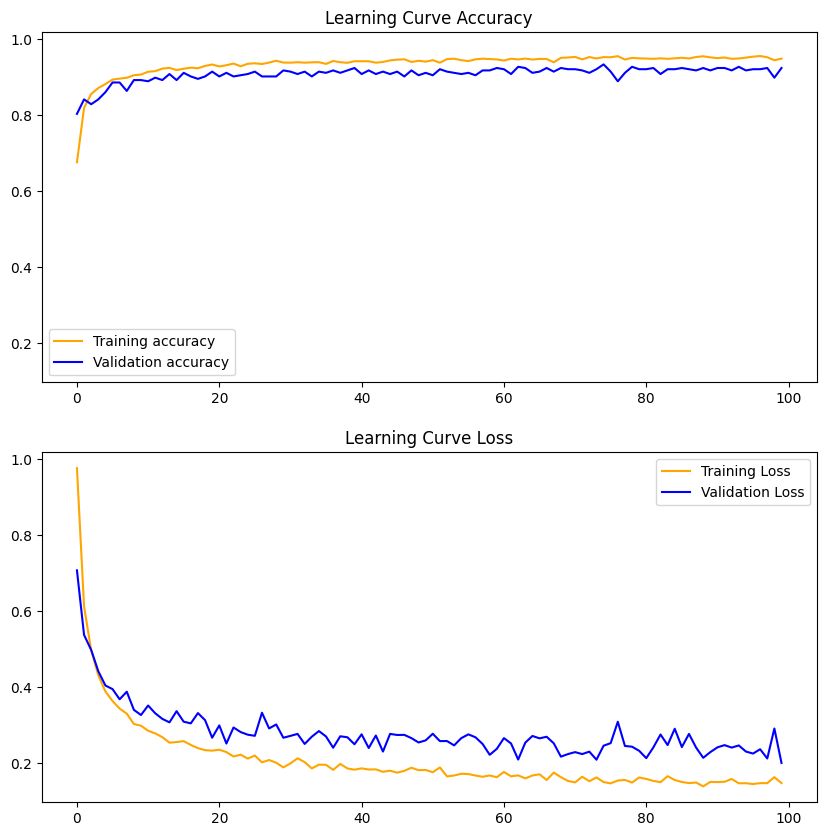

In [ ]:
acc = train_results.history['accuracy']
val_acc = train_results.history['val_accuracy']
loss = train_results.history['loss']
val_loss = train_results.history['val_loss']

epochs = range(len(acc))

fig, ax = plt.subplots (nrows=2, ncols=1, sharey=True, figsize=(10, 10))

ax[0].plot(epochs, acc, 'orange', label='Training accuracy')
ax[0].plot(epochs, val_acc, 'b', label='Validation accuracy')
ax[0].set(title='Learning Curve Accuracy')
ax[0].legend()

ax[1].plot(epochs, loss, 'orange', label='Training Loss')
ax[1].plot(epochs, val_loss, 'b', label='Validation Loss')
ax[1].set(title='Learning Curve Loss')
ax[1].legend()

plt.show()

## Evaluation

In [ ]:
img_class_labels = testing_generator.class_indices
inverse_img_class_labels = {v:k for k,v in img_class_labels.items()}
predicted_prob = model.predict(testing_generator)
y_test = testing_generator.classes
y_test = [inverse_img_class_labels[pred] for pred in y_test]
predicted = [inverse_img_class_labels[np.argmax(pred)] for pred in predicted_prob]

315/315 [==============================] - 20s 57ms/step


              precision    recall  f1-score   support

    Basophil       0.95      0.97      0.96        63
  Eosinophil       0.88      1.00      0.93        63
  Lymphocyte       0.96      0.76      0.85        63
    Monocyte       0.73      0.95      0.83        63
  Neutrophil       0.98      0.73      0.84        63

    accuracy                           0.88       315
   macro avg       0.90      0.88      0.88       315
weighted avg       0.90      0.88      0.88       315



(array([0.5, 1.5, 2.5, 3.5, 4.5]),
 [Text(0, 0.5, 'Basophil'),
  Text(0, 1.5, 'Eosinophil'),
  Text(0, 2.5, 'Lymphocyte'),
  Text(0, 3.5, 'Monocyte'),
  Text(0, 4.5, 'Neutrophil')])

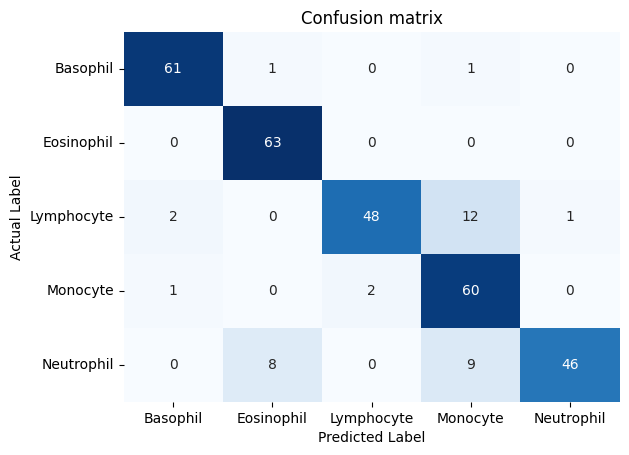

In [ ]:
print(metrics.classification_report(y_test, predicted))
cm = metrics.confusion_matrix(y_test, predicted)
fig, ax = plt.subplots()
sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap=plt.cm.Blues,
            cbar=False)
ax.set(xlabel="Predicted Label", ylabel="Actual Label", xticklabels=img_class_labels,
       yticklabels=img_class_labels, title="Confusion matrix")
plt.yticks(rotation=0)

## Save

In [ ]:
model.save('swin_keras_eph100.keras')

In [ ]:
model.save('swin_keras_eph100')

INFO:tensorflow:Assets written to: swin_keras_eph100\assets


INFO:tensorflow:Assets written to: swin_keras_eph100\assets
